In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

df = pd.read_csv("hotel_bookings.csv")
df.head()
df_numeric = df.select_dtypes(include = "number")
df_numeric
df_numeric.columns

Index(['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')

In [14]:
len(df.select_dtypes(include = "number").columns)

20

In [15]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [20]:
df["adr"].mean()

np.float64(101.83112153446687)

In [18]:
df['adr'].median()

np.float64(94.575)

In [19]:
df["meal"].mode()

0    BB
Name: meal, dtype: object

In [29]:
df['adr'].var()

np.float64(2553.8660997849593)

In [31]:
np.std(df['adr'])
df['adr'].std()

np.float64(50.53579028554871)

In [3]:
print("Mean : " , df['lead_time'].mean().round(2) , "median : " , df['lead_time'].median().round(2) , "variance :" , df['lead_time'].var().round(2) , "standard Deviation : " , df['lead_time'].std().round(2))
df['lead_time'].agg(['mean' , 'median' , 'var' , 'std']) 

Mean :  104.01 median :  69.0 variance : 11419.72 standard Deviation :  106.86


mean        104.011416
median       69.000000
var       11419.721511
std         106.863097
Name: lead_time, dtype: float64

In [12]:
df_numeric = df.select_dtypes(include = ["number"])
maxi = 0
feature = ''
for i in df_numeric.columns:
    if df_numeric[i].std() > maxi: 
        maxi = df_numeric[i].std()
        feature = i
print(feature , maxi)

#OR
df_numeric.std().idxmax()

company 131.65501463851223


'company'

In [15]:
df_numeric.std().sort_values(ascending = True).head(1)
# Or
df_numeric.std().idxmin()

'babies'

In [10]:
df_numeric = df.select_dtypes(include = ["number"]) 
for i in df_numeric.columns:
    Q1 = df_numeric[i].quantile(0.25)
    Q3 = df_numeric[i].quantile(0.75) 
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    if ((df_numeric[i] < lower ) | ( df_numeric[i] > upper )).any(): 
        print(i)

lead_time
stays_in_weekend_nights
stays_in_week_nights
adults
children
babies
is_repeated_guest
previous_cancellations
previous_bookings_not_canceled
booking_changes
days_in_waiting_list
adr
required_car_parking_spaces
total_of_special_requests


In [14]:
maxi = 0 
feature = ''
for i in df_numeric.columns:
    if maxi < df_numeric[i].var() :
        maxi = df_numeric[i].var()
        feature = i
print(feature,maxi)

#OR
df_numeric.var().idxmax()

company 17333.04287946687


'company'

In [21]:
df_numeric.agg(["mean" , 'median' , 'var' , 'std']).T
# OR
df_numeric.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


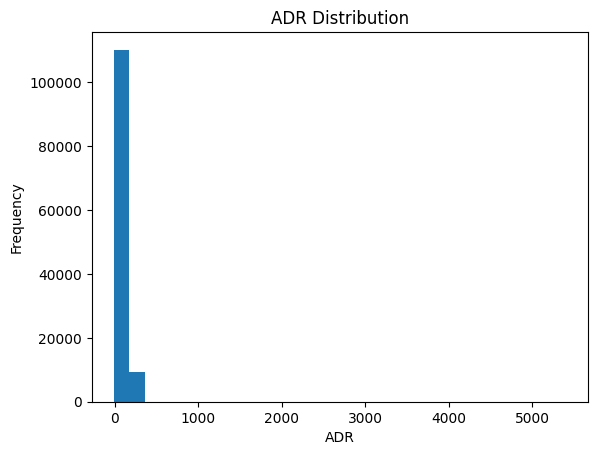

In [23]:
plt.hist(df["adr"] , bins = 30)
plt.title("ADR Distribution")
plt.xlabel("ADR")
plt.ylabel("Frequency")

plt.show()

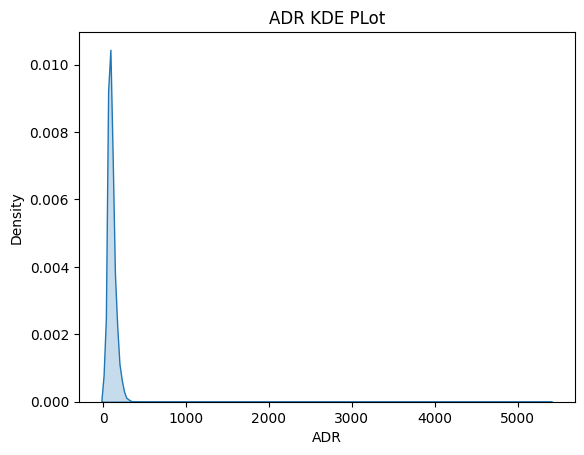

In [27]:
sns.kdeplot(df['adr'] , fill = True)
plt.title("ADR KDE PLot")
plt.xlabel("ADR")
plt.show()

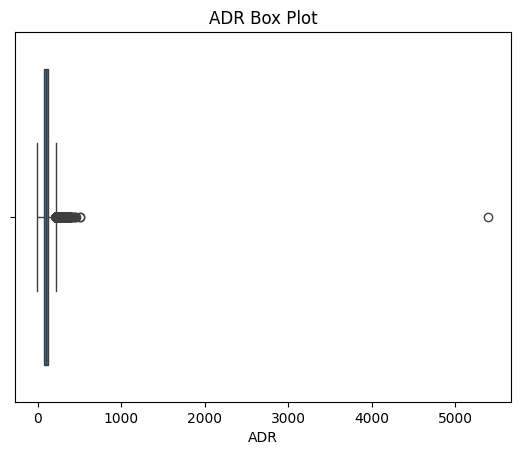

In [32]:
sns.boxplot(x = df['adr'])
plt.title("ADR Box Plot")
plt.xlabel("ADR")
plt.show()

In [35]:
df_numeric.skew()

is_canceled                        0.536678
lead_time                          1.346550
arrival_date_year                 -0.232583
arrival_date_week_number          -0.010014
arrival_date_day_of_month         -0.002000
stays_in_weekend_nights            1.380046
stays_in_week_nights               2.862249
adults                            18.317805
children                           4.112590
babies                            24.646545
is_repeated_guest                  5.326315
previous_cancellations            24.458049
previous_bookings_not_canceled    23.539800
booking_changes                    6.000270
agent                              1.089386
company                            0.601600
days_in_waiting_list              11.944353
adr                               10.530214
required_car_parking_spaces        4.163233
total_of_special_requests          1.349189
dtype: float64

In [36]:
df_numeric.kurtosis()

is_canceled                         -1.712005
lead_time                            1.696449
arrival_date_year                   -0.994564
arrival_date_week_number            -0.986077
arrival_date_day_of_month           -1.187168
stays_in_weekend_nights              7.174066
stays_in_week_nights                24.284555
adults                            1352.115116
children                            18.673692
babies                            1633.948235
is_repeated_guest                   26.370077
previous_cancellations             674.073693
previous_bookings_not_canceled     767.245210
booking_changes                     79.393605
agent                               -0.007180
company                             -0.490795
days_in_waiting_list               186.793070
adr                               1013.189851
required_car_parking_spaces         29.998056
total_of_special_requests            1.492565
dtype: float64

In [45]:
std = df_numeric.std()
std_TF = std > 100
std_TF[std_TF].index

Index(['lead_time', 'agent', 'company'], dtype='object')

In [47]:
median = df_numeric.median() 
median_TF = median > df_numeric.mean()
k = median_TF[median_TF]
k.index

Index(['arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'adults'],
      dtype='object')

In [52]:
isnull = df_numeric.isnull().sum()
k = isnull > 0 
k_T = k[k]
k_T.index

Index(['children', 'agent', 'company'], dtype='object')

In [7]:
outlier = []
for i in df_numeric.columns:
    Q1 = df_numeric[i].quantile(0.25)
    Q3 = df_numeric[i].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    if ((df_numeric[i] < lower) | (df_numeric[i] > upper)).any() : 
        outlier.append(i)
std = df_numeric.std()
std_tf = std > 100
k = std_tf[std_tf]
set(outlier).intersection(k.index)

{'lead_time'}

In [11]:
df.groupby("hotel")['adr'].mean().sort_values(ascending = False)

hotel
City Hotel      105.304465
Resort Hotel     94.952930
Name: adr, dtype: float64

In [29]:
(df.groupby('market_segment')['is_canceled'].mean()).round(2)

market_segment
Aviation         0.22
Complementary    0.13
Corporate        0.19
Direct           0.15
Groups           0.61
Offline TA/TO    0.34
Online TA        0.37
Undefined        1.00
Name: is_canceled, dtype: float64

In [3]:
booking_count = df["country"].value_counts()

valid_countries = booking_count[booking_count >= 100].index

df[df["country"].isin(valid_countries)] \
    .groupby("country")["adr"] \
    .mean() \
    .sort_values(ascending=False)

country
MAR    134.395521
LUX    132.393380
USA    122.992251
CHE    121.830133
NOR    121.633015
JPN    121.240355
RUS    118.700475
ARG    117.761589
DNK    117.582805
AGO    117.122928
ESP    116.995463
AUS    116.775258
ROU    115.032720
ITA    113.948208
BEL    113.847784
IND    113.608158
KOR    113.219398
HUN    113.178652
SWE    112.897002
DZA    112.536117
TUR    112.119960
CZE    111.337778
HRV    111.024200
BRA    111.005337
ISR    110.695815
CHN    110.538939
GRC    109.962734
FRA    109.617276
CN     108.688444
NLD    108.085480
POL    107.099140
AUT    106.239580
DEU    104.396756
FIN    104.032640
SRB     99.430099
IRL     98.192172
GBR     96.022058
PRT     92.041483
Name: adr, dtype: float64

In [5]:
df.groupby('customer_type')['lead_time'].mean().sort_values(ascending = False)

customer_type
Contract           142.969823
Transient-Party    137.037056
Transient           93.295515
Group               55.057192
Name: lead_time, dtype: float64

In [7]:
df[df["is_canceled"] == 0].groupby("distribution_channel")["adr"].mean().sort_values(ascending=False)

distribution_channel
GDS          119.933462
Undefined    112.700000
Direct       106.038609
TA/TO        101.617635
Corporate     67.247982
Name: adr, dtype: float64